In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from matplotlib.lines import Line2D

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.mpl.ticker as cticker
import matplotlib.dates as mdates
import numpy as np

import intake

import sys
sys.path.append("/work/mh1498/m301248/TCO_data/COARE-algorithm/Python/COARE3.5/") 
sys.path.append("/work/mh1498/m301248/TCO_data/BCO_observational/mass_fluxes_profiles/yk22_mass_fluxes.py")

import metpy

import meteo


import pandas as pd
from IPython.display import display, HTML


import yk22_mass_fluxes

In [2]:
%load_ext autoreload
%autoreload 2

## what is the reference layer to compute mixed layer AVERAGED quantities?
mixed_avg_levels   = slice(200, 500)

Rd = 287.
cp = 1004. # j / kg K
Lv = 2.5e6 # J/kg
g = 9.81   # m/s2


Fa_q_eu, Fa_q_or    = (-2e-3)/86400. , (-0.e-3)/86400.   # kg/kg / day
Fa_th_eu , Fa_th_or = -0.75/86400.,       -0./86400.        # K/day
bl_height        = 500.                                    #  mean mixed layer height / m
bl_density       = 1. 


## what height is entrained air from?
entrainment_levels = slice(600, 850)    # m

## what height does convective downdrafts come from?
downdraft_levels_eu = slice(1000, 2000)
downdraft_levels_or = slice(2500, 3500)

In [3]:
min_hgt = 40.

level2_path = "/work/mh1498/m301248/TCO_data/eurec4a_profiles_level2/EUREC4A_BCO_Vaisala-RS_L2_v3.0.0.nc"
ds_eureca = xr.open_dataset(level2_path)
ds_eureca_bco = ds_eureca.where(((ds_eureca["platform"] == 1)&(ds_eureca["ascent_flag"]==1)&(ds_eureca.alt>min_hgt)), drop=True)
## renaming for common ground
ds_eureca_bco = ds_eureca_bco.swap_dims({"sounding": "launch_time"})
ds_eureca_bco = ds_eureca_bco.rename({"alt":"height"})


ds_orcestra = xr.open_dataset("ipfs://bafybeid7cnw62zmzfgxcvc6q6fa267a7ivk2wcchbmkoyk4kdi5z2yj2w4", engine="zarr")
ds_orcestra
ds_orcestra_bco = ds_orcestra.where(((ds_orcestra["platform"] == "BCO")&(ds_orcestra["ascent_flag"]==0)&(ds_orcestra.height>min_hgt)), drop=True)


In [36]:
## TO USE IN SOLVER find_theta_for_pair
## h_{cd} - s_{cd} - Lv*q_sat(s_{cd}/cp) = 0
## where I find theta as cp*\theta = s_cd
def temp_from_h(theta, p, h_cd, Lv, cp, sat_frac):
    # input:
    # - p : pressure in hPa
    # - h_cd : moist static energy at convective downdraft level, J/kg
    # - Lv : latent heat of vaporization = 2.5e6 J/kg
    # - cp : specific heat dry air = 1004.67 J/kg K
    # - sat_frac : fraction of saturation, to test when different from 1.

    T = theta*(p/1000.)**(Rd/cp) - 273.15 #*(p/1000.)**(Rd/cp) - 273.15
    es = 6.1121 * np.exp(17.502 * T / (240.97 + T))
    es = es * (1.0007 + p * 3.46e-6)
    ex = meteo.qsat(T,p)
    es = 0.98 * ex
    qs = 0.622 * es /(p - 0.378 * es)


    # T = theta - 273.15 #*(p/1000.)**(Rd/cp) - 273.15
    # es = 6.1121 * np.exp(17.502 * T / (240.97 + T) )     # TRY HERE TO USE theta*(p/1000.)**(R/cp) - returns physically consistent values, but mass fluxes become negative :/
    # denominator = p - 0.378 * es * (1.0007 + p * 3.46e-4)
    
    return h_cd/cp - theta - sat_frac*(Lv / cp)*qs #0.622*es*(1.0007 + p * 3.46e-6) / denominator

from scipy.optimize import root_scalar
def find_theta_for_pair(p, h, sat_frac):
    
    f = lambda t : temp_from_h(t, p=p, h_cd=h, Lv=Lv, cp=cp, sat_frac=sat_frac)

    try:
        sol = root_scalar(f, bracket=[270,350], method='brentq')
        return sol.root if sol.converged else np.nan
    except:
        return np.nan
    
# Vectorize the function
vectorized_theta_root = np.vectorize(find_theta_for_pair)


## this function aims at extracting the thermodynamical properties 
## from entrainment heights and downdrafts, from a single profile at a time
def properties_from_profile(profile, mixed_avg_levels, entrainment_levels, downdraft_levels, CD_sat_frac, vert_dim):

    h_cd = (cp*profile["ta"] + Lv*profile["q"] + g*profile[vert_dim]).sel({vert_dim:downdraft_levels})
    p_cd = profile["p"].sel({vert_dim:downdraft_levels}).values/100.  ## hPa

    cd_levels = profile[vert_dim].sel({vert_dim:downdraft_levels}).values

    thetaD = (vectorized_theta_root( p_cd , h_cd, sat_frac=CD_sat_frac))
    thetaD = xr.DataArray(thetaD, dims=[vert_dim], coords={vert_dim:cd_levels, "p_cd": (vert_dim, p_cd)})
    thetaD = thetaD.rename({vert_dim:"height_cd"})

    qD = CD_sat_frac*(meteo.qsea((thetaD)-273.15 , p_cd)/1e3)
    qD = xr.DataArray(qD, dims=[vert_dim], coords={vert_dim:cd_levels, "p_cd": (vert_dim, p_cd)})
    qD = qD.rename({vert_dim:"height_cd"})



    theta_out = profile.theta.sel({vert_dim:entrainment_levels})  #.rename({vert_dim:"height_e"})
    theta_bl  = profile.theta.sel({vert_dim:mixed_avg_levels}).mean(dim = vert_dim) #.rename({vert_dim:"height_e"})

    q_out = profile.q.sel({vert_dim:entrainment_levels})  #.rename({vert_dim:"height_e"})
    q_bl  = profile.q.sel({vert_dim:mixed_avg_levels}).mean(dim = vert_dim) #.rename({vert_dim:"height_e"})


    return xr.Dataset(
        dict(
            thetaD=thetaD,
            qD=qD,
            theta_out=theta_out,
            theta_bl=theta_bl,
            q_out=q_out,
            q_bl=q_bl
        )
        )


In [37]:
mean_prof_eu = ds_eureca_bco.mean(dim="launch_time")
props_eu = properties_from_profile(mean_prof_eu, mixed_avg_levels, entrainment_levels, downdraft_levels_eu, CD_sat_frac=1., vert_dim="height")


mean_prof_or = ds_orcestra_bco.mean(dim="launch_time")
props_or = properties_from_profile(mean_prof_or, mixed_avg_levels, entrainment_levels, downdraft_levels_or, CD_sat_frac=1., vert_dim="height")


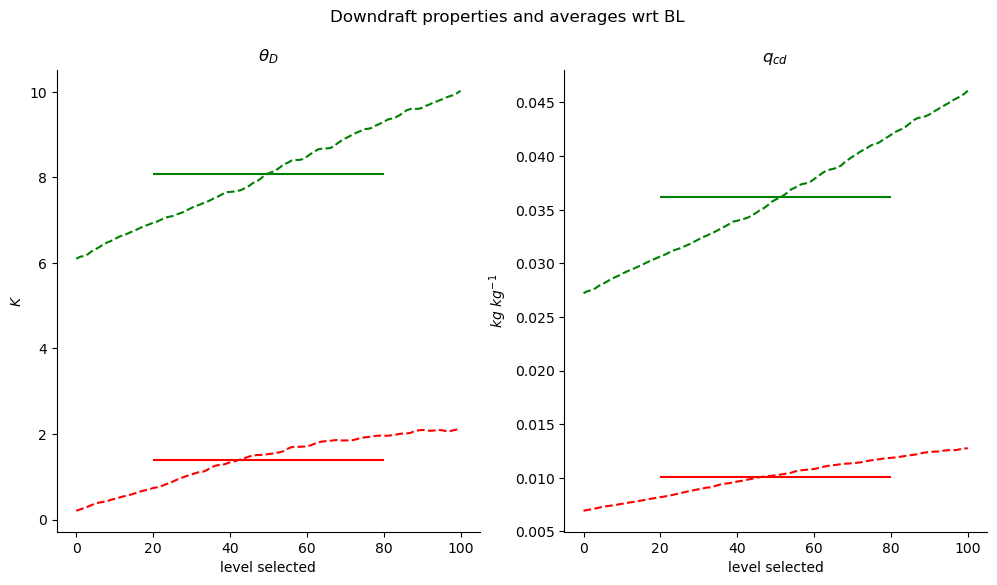

In [38]:
fig, ax = plt.subplots(1,2, figsize=(12, 6))
fig.suptitle("Downdraft properties and averages wrt BL")

ax[0].plot(props_eu["thetaD"] - props_eu["theta_bl"], "--", color="red", label="EUREC4A")
ax[0].plot(props_or["thetaD"] - props_or["theta_bl"], "--", color="green", label="ORCESTRA")

ax[0].hlines(xmin=20, xmax=80, y=props_eu["thetaD"].weighted((props_eu["thetaD"].p_cd).diff(dim="height_cd", n=1)).mean() - props_eu["theta_bl"], color="red", label="EUREC4A")
ax[0].hlines(xmin=20, xmax=80, y=props_or["thetaD"].weighted((props_or["thetaD"].p_cd).diff(dim="height_cd", n=1)).mean() - props_or["theta_bl"], color="green", label="ORCESTRA")

ax[0].set_xlabel("level selected")
ax[0].set_ylabel(r"$K$")
ax[0].set_title(r"$\theta_D$")



ax[1].plot(props_eu["qD"] - props_eu["q_bl"], "--", color="red", label="EUREC4A")
ax[1].plot(props_or["qD"] - props_or["q_bl"], "--", color="green", label="ORCESTRA")

ax[1].hlines(xmin=20, xmax=80, y=props_eu["qD"].weighted((props_eu["qD"].p_cd).diff(dim="height_cd", n=1)).mean() - props_eu["q_bl"], color="red", label="EUREC4A")
ax[1].hlines(xmin=20, xmax=80, y=props_or["qD"].weighted((props_or["qD"].p_cd).diff(dim="height_cd", n=1)).mean() - props_or["q_bl"], color="green", label="ORCESTRA")

ax[1].set_xlabel("level selected")
ax[1].set_ylabel(r"$kg~kg^{-1}$")
ax[1].set_title(r"$q_{cd}$")

for x in ax:
    for spine in ['top', 'right']:
        x.spines[spine].set_visible(False)

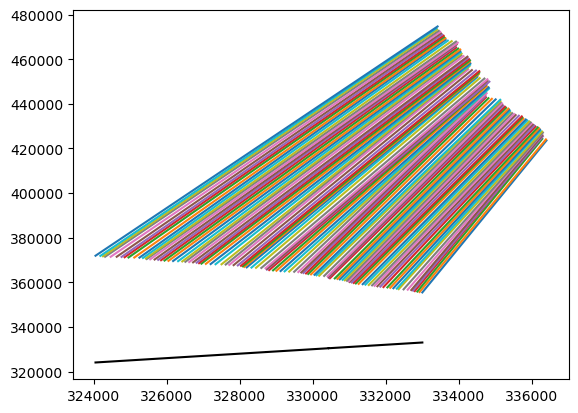

In [39]:
h_eu = (cp*mean_prof_eu["ta"] + Lv*mean_prof_eu["q"] + g*mean_prof_eu["height"]).sel(height=downdraft_levels_eu)
h_or = (cp*mean_prof_or["ta"] + Lv*mean_prof_or["q"] + g*mean_prof_or["height"]).sel(height=downdraft_levels_or)

rec_h_eu = cp*props_eu["thetaD"] + Lv*props_eu["qD"]
rec_h_or = cp*props_or["thetaD"] + Lv*props_or["qD"]


plt.plot([h_eu, h_or], [rec_h_eu, rec_h_or])
plt.plot(h_eu, h_eu, "k")
plt.show()

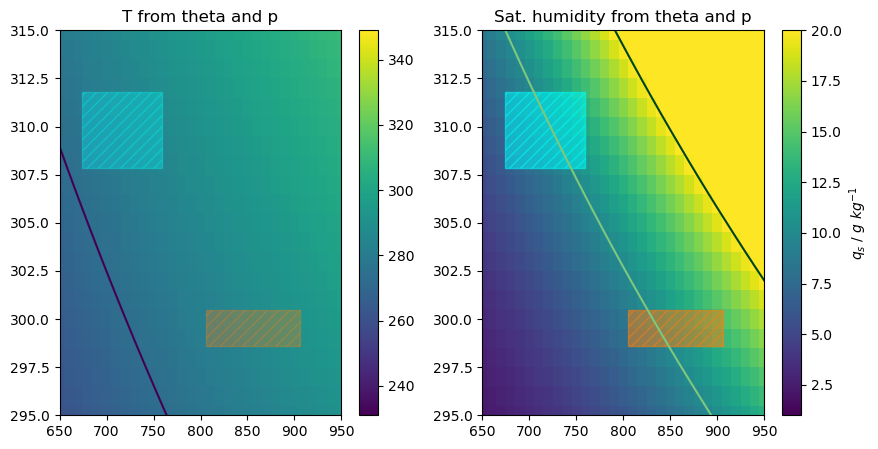

In [62]:
def T(theta, p):
    return theta*(p/1000.)**(Rd/cp)


def qs_from_theta(theta, p):
    T = theta*(p/1000.)**(Rd/cp) - 273.15 #*(p/1000.)**(Rd/cp) - 273.15
    es = 6.1121 * np.exp(17.502 * T / (240.97 + T))
    es = es * (1.0007 + p * 3.46e-4)
    ex = meteo.qsat(T,p)
    es = 0.98 * ex
    qs = 622 * es /(p - 0.378 * es)
    return qs



p = np.arange(1000, 500, -10)
theta = np.arange(280, 350)
P, Theta = np.meshgrid(p, theta)


fig, ax = plt.subplots(1, 2, figsize=(10, 5))

c = ax[0].pcolormesh(P, Theta, T(Theta, P))
ax[0].contour(P, Theta, T(Theta, P), levels=[273.15])
ax[0].set_title("T from theta and p")
fig.colorbar(c, ax=ax[0])


c = ax[1].pcolormesh(P, Theta, qs_from_theta(Theta, P), vmin=1., vmax=20.)
ax[1].contour(P, Theta, qs_from_theta(Theta, P), levels=[1, 10, 20], cmap="Greens")
ax[1].set_title("Sat. humidity from theta and p")
fig.colorbar(c, ax=ax[1], label=r"$q_s$ / $g~kg^{-1}$")

ax[1].fill_between([props_eu["p_cd"].min(), props_eu["p_cd"].max()], props_eu["thetaD"].min(), props_eu["thetaD"].max(), alpha=0.3, color='tab:orange', hatch="///")
ax[1].fill_between([props_or["p_cd"].min(), props_or["p_cd"].max()], props_or["thetaD"].min(), props_or["thetaD"].max(), alpha=0.3, color='cyan', hatch="///")




for x in ax:
    x.fill_between([props_eu["p_cd"].min(), props_eu["p_cd"].max()], props_eu["thetaD"].min(), props_eu["thetaD"].max(), alpha=0.3, color='tab:orange', hatch="///")
    x.fill_between([props_or["p_cd"].min(), props_or["p_cd"].max()], props_or["thetaD"].min(), props_or["thetaD"].max(), alpha=0.3, color='cyan', hatch="///")

    x.set_xlim(650, 950)
    x.set_ylim(295, 315)